<a href="https://colab.research.google.com/github/Loknath73/Skin-Cancer/blob/main/Skin_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import os
import imghdr
import numpy as np
from matplotlib import pyplot as pyplot
import pandas as pd

/tmp/ipykernel_499/802866750.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [2]:
from google.colab import files
Train_Dataset = files.upload()
!unzip -q "archive (1).zip" -d train_data

Saving archive (1).zip to archive (1) (1).zip


In [3]:
from google.colab import files
Test_Dataset =files.upload()
!unzip -q "archive (1) (1).zip" -d test_data

Saving archive (1).zip to archive (1) (2).zip


In [4]:
import os

# Check if the folders were created successfully
print("Train data class folders:", os.listdir('train_data'))
print("Test data class folders:", os.listdir('test_data'))

Train data class folders: ['melanoma_cancer_dataset']
Test data class folders: ['melanoma_cancer_dataset']


In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# 1. SET DATA PATHS (Updated based on your folder structure)
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Pointing directly inside the 'melanoma_cancer_dataset' folder
TRAIN_DIR = 'train_data/melanoma_cancer_dataset/train'
TEST_DIR = 'test_data/melanoma_cancer_dataset/test'

# 2. DATA AUGMENTATION & PREPROCESSING
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Keeping 20% data for live validation tracking
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Training Data Loader
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

# Validation Data Loader
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

# Test Data Loader
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# 3. BUILD CNN MODEL (Using MobileNetV2 Transfer Learning)Loknath73
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# 4. COMPILE THE MODEL
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 5. START TRAINING (This will take some time depending on dataset size)
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Found 7684 images belonging to 2 classes.
Found 1921 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 558s 2s/step - accuracy: 0.8295 - loss: 0.3807 - val_accuracy: 0.8745 - val_loss: 0.3091
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.8628 - loss: 0.3222 - val_accuracy: 0.8699 - val_loss: 0.3049
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 585s 2s/step - accuracy: 0.8731 - loss: 0.3049 - val_accuracy: 0.8777 - val_loss: 0.2933
Epoch 4/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 536s 2s/step - accuracy: 0.8803 - loss: 0.2834 - val_accuracy: 0.8917 - val_loss: 0.2659
Epoch 5/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 543s 2s/step - accuracy: 0.8801 - loss: 0.2801 - val_accuracy: 0.8886 - val_loss: 0.2710
Epoch 6/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 548s 2s/step - accuracy: 0.8790 - loss: 0.2825 - val_accuracy: 0.8860 - val_loss: 0.2706
Epoch 7/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 529s 2s/ste

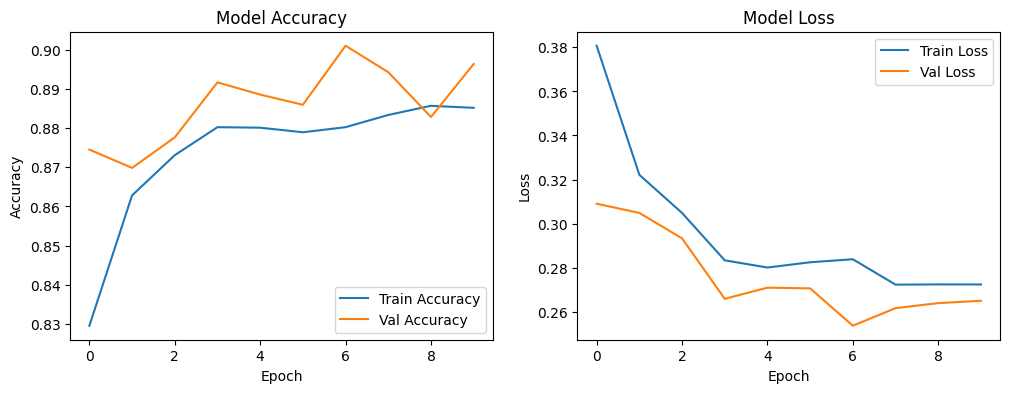

In [9]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 4))

# Accuracy Graph
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [10]:

test_loss, test_acc = model.evaluate(test_generator)
print(f"\n (Final Test Accuracy): {test_acc * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.9090 - loss: 0.2444

 (Final Test Accuracy): 90.90%


In [11]:

model.save('skin_cancer_detector_model.h5')
print("Model saved successfully as 'skin_cancer_detector_model.h5'")

Model saved successfully as 'skin_cancer_detector_model.h5'


In [12]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_skin_mole(img_path):
    # Load and preprocess the image exactly like the training data
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Get the model's prediction
    prediction = model.predict(img_array)

    print("-" * 40)
    if prediction[0][0] > 0.5:
        confidence = prediction[0][0] * 100
        print(f"Prediction: MALIGNANT (Cancerous Mole Detected)")
        print(f"Confidence Score: {confidence:.2f}%")
    else:
        confidence = (1 - prediction[0][0]) * 100
        print(f"Prediction: BENIGN (Healthy Skin Mole)")
        print(f"Confidence Score: {confidence:.2f}%")
    print("-" * 40)

# Put any image path here to test it live!
predict_skin_mole('test_data/melanoma_cancer_dataset/test/malignant/melanoma_10105.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
----------------------------------------
Prediction: BENIGN (Healthy Skin Mole)
Confidence Score: 79.37%
----------------------------------------
